In [1]:
import os
import numpy as np
import pandas as pd
import anndata as ad
import pertpy as pt
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import scipy.stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from itertools import combinations
from scipy.stats import pearsonr

plt.rcParams['pdf.fonttype'] = 42
mpl.rcParams['font.family'] = 'NimbusSanL'


/Users/rzhu/miniconda3/envs/deseq/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/Users/rzhu/miniconda3/envs/deseq/lib/python3.11/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/Users/rzhu/miniconda3/envs/deseq/lib/python3.11/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


# 1. Data Loading

In [ ]:
# base_dir = "../../../../3_expts/Cell_culture_experiments/TCRcluster_validation"
# results_dir = "results"
# os.makedirs(results_dir, exist_ok=True)

# result_folders = ['K55P9X_results', '79YHFD_results', 'QBNZP2_results', 'SWVVMG_results']


In [3]:
# # Load expression matrices from each sequencing batch and merge on gene annotations
# dfs = []
# for folder in sorted(result_folders):
#     prefix = folder.replace("_results", "")
#     folder_path = os.path.join(base_dir, folder)

#     expr = pd.read_csv(os.path.join(folder_path, f"{prefix}-expression-matrix.tsv"), sep="\t")
#     sample_map = pd.read_csv(os.path.join(folder_path, f"{prefix}_sample_name.csv"), encoding="utf-8-sig")

#     rename_map = {}
#     for _, row in sample_map.iterrows():
#         idx = int(row["sample_index"])
#         name = row["sample_name"]
#         rename_map[f"{prefix}_{idx}_cpm"] = f"{name}_cpm"
#         rename_map[f"{prefix}_{idx}_count"] = f"{name}_count"

#     dfs.append(expr.rename(columns=rename_map))
#     print(f"{prefix}: {len(sample_map)} samples")

# combined = dfs[0]
# for df in dfs[1:]:
#     combined = combined.merge(df, on=["gene_id", "gene_name", "gene_biotype"], how="outer")
# print(f"Combined matrix: {combined.shape}")


79YHFD: 30 samples
K55P9X: 30 samples
QBNZP2: 30 samples
SWVVMG: 30 samples
Combined matrix: (78986, 243)


In [4]:
# count_cols = [c for c in combined.columns if c.endswith('_count')]
# gene_meta = combined[['gene_id', 'gene_name', 'gene_biotype']].set_index('gene_id')
# counts = combined.set_index('gene_id')[count_cols]

# # Parse sample metadata from column names
# # Format: Donor{X}_{Condition}_{Replicate}_{Perturbation}_count  (4-part)
# #      or Donor{X}_{Condition}_{Perturbation}_count              (3-part, legacy)
# # For Stim8hr/Stim48hr, the same donor was processed in two replicate batches
# # (Rep1, Rep2). Following the bulkRNAseq_analysis convention of prefixing donor
# # with batch (sample_meta['donor'] = batch + '_' + donor), we fold the replicate
# # into the donor label so DESeq2 treats each (donor, replicate) as a distinct
# # donor level and absorbs the replicate-batch effect.
# BATCHED_CONDITIONS = {'Stim8hr', 'Stim48hr'}
# PERTURBATION_RENAME = {'HEXDC': 'HEXD'}
# obs_data = []
# for col in count_cols:
#     sample = col.rsplit('_count', 1)[0]
#     parts = sample.split('_')
#     donor_id = parts[0]
#     condition = parts[1]
#     replicate, perturbation = (parts[2], parts[3]) if len(parts) == 4 else ('Rep1', parts[2])
#     perturbation = PERTURBATION_RENAME.get(perturbation, perturbation)
#     donor = f'{donor_id}_{replicate}' if condition in BATCHED_CONDITIONS else donor_id
#     obs_data.append({
#         'donor': donor,
#         'donor_id': donor_id,
#         'condition': condition,
#         'replicate': replicate,
#         'perturbation': perturbation,
#         'target_gene': 'Non-targeting' if 'NTC' in perturbation else perturbation
#     })

# obs_df = pd.DataFrame(obs_data, index=count_cols)

# # Optionally restrict to specific donors (set to None to use all)
# donors_to_use = None  # e.g. ['DonorD', 'DonorE']
# if donors_to_use is not None:
#     keep = obs_df['donor_id'].isin(donors_to_use)
#     obs_df = obs_df.loc[keep]
#     counts = counts.loc[:, keep]

# conditions = sorted(obs_df['condition'].unique())
# perturbations = sorted(p for p in obs_df['perturbation'].unique() if 'NTC' not in p)
# print(f"Donors:       {sorted(obs_df['donor'].unique())}")
# print(f"Conditions:   {conditions}")
# print(f"Perturbations:{perturbations}")
# print(f"Total samples:{len(obs_df)}")

Donors:       ['DonorD_Rep1', 'DonorD_Rep2', 'DonorE_Rep1', 'DonorE_Rep2', 'DonorH_Rep1', 'DonorH_Rep2']
Conditions:   ['Stim48hr', 'Stim8hr']
Perturbations:['ATP2A2', 'ATP2A3', 'CD3G', 'GPI', 'HEXD', 'LAT', 'MEN1', 'SIK3', 'VAV1']
Total samples:120


# 2. PCA Examination of Batch Effects

Genes retained for PCA: 15472


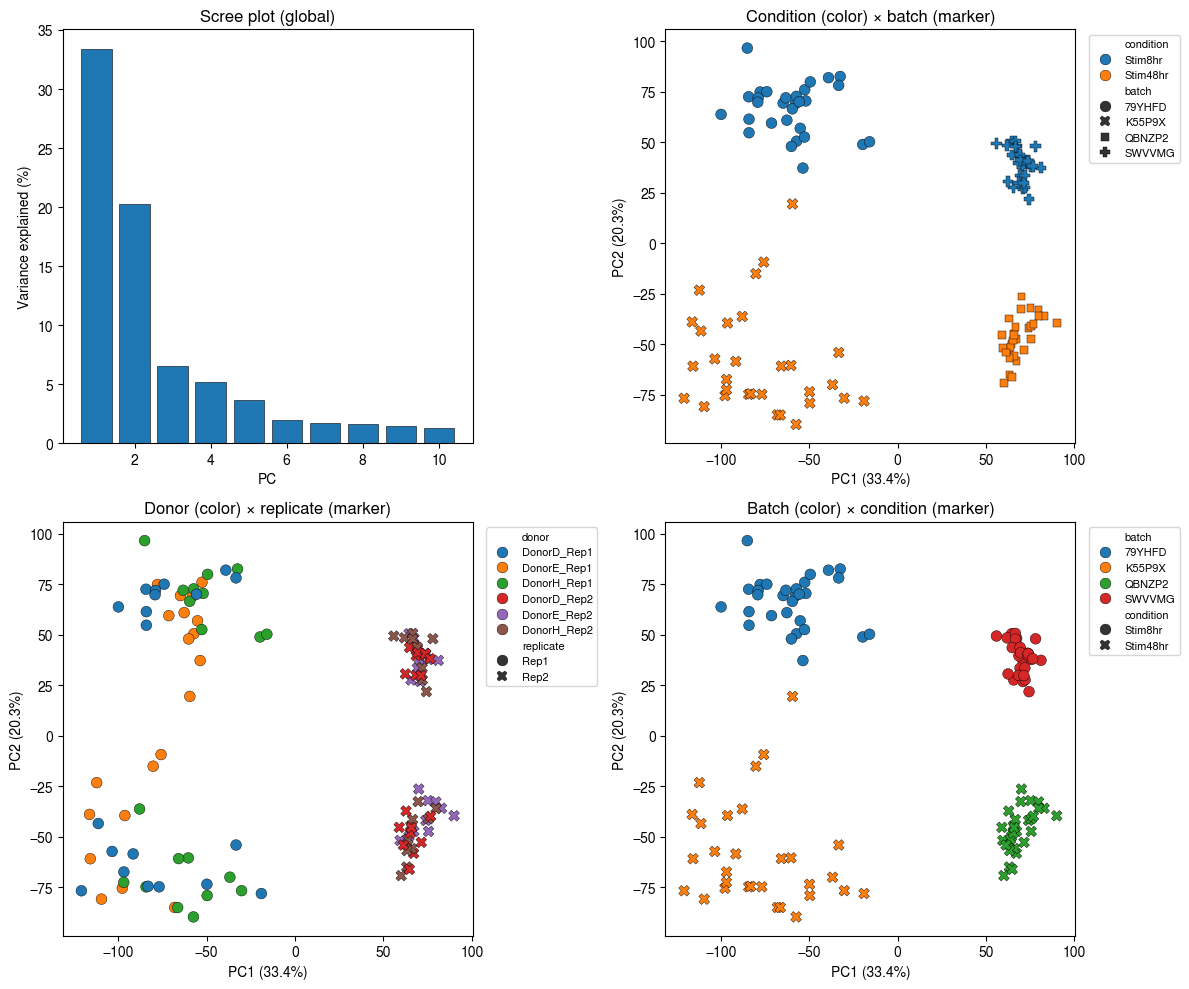

In [5]:
# # Add sequencing batch label (each result folder = one batch)
# batch_map = {}
# for folder in sorted(result_folders):
#     prefix = folder.replace("_results", "")
#     smap = pd.read_csv(os.path.join(base_dir, folder, f"{prefix}_sample_name.csv"), encoding="utf-8-sig")
#     for _, row in smap.iterrows():
#         batch_map[f"{row['sample_name']}_count"] = prefix
# obs_df['batch'] = obs_df.index.map(batch_map)

# # Log-CPM on protein-coding genes expressed (CPM >= 1) in at least 3 samples
# is_pc = gene_meta['gene_biotype'] == 'protein_coding'
# cpm_cols = [c.replace('_count', '_cpm') for c in count_cols]
# cpm_pc = combined.set_index('gene_id').loc[is_pc, cpm_cols]
# cpm_pc.columns = count_cols
# cpm_pc = cpm_pc[obs_df.index]  # align with current sample set
# keep_genes = (cpm_pc > 1).sum(axis=1) >= 3
# log_cpm = np.log2(cpm_pc.loc[keep_genes] + 1)
# print(f"Genes retained for PCA: {log_cpm.shape[0]}")

# # Global PCA
# X_scaled = StandardScaler().fit_transform(log_cpm.T)
# pca_global = PCA(n_components=10).fit(X_scaled)
# ev = pca_global.explained_variance_ratio_
# pca_df = pd.DataFrame(
#     pca_global.transform(X_scaled),
#     columns=[f'PC{i+1}' for i in range(10)],
#     index=obs_df.index
# ).join(obs_df)

# fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# axes[0, 0].bar(range(1, 11), ev * 100, edgecolor='k', linewidth=0.4)
# axes[0, 0].set_xlabel('PC'); axes[0, 0].set_ylabel('Variance explained (%)')
# axes[0, 0].set_title('Scree plot (global)')

# for ax, hue, style, title in [
#     (axes[0, 1], 'condition', 'batch',      'Condition (color) × batch (marker)'),
#     (axes[1, 0], 'donor',     'replicate',  'Donor (color) × replicate (marker)'),
#     (axes[1, 1], 'batch',     'condition',  'Batch (color) × condition (marker)'),
# ]:
#     sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue=hue, style=style,
#                     ax=ax, s=60, edgecolor='k', linewidth=0.3)
#     ax.set_xlabel(f'PC1 ({ev[0]:.1%})'); ax.set_ylabel(f'PC2 ({ev[1]:.1%})')
#     ax.set_title(title)
#     ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

# plt.tight_layout()
# plt.show()


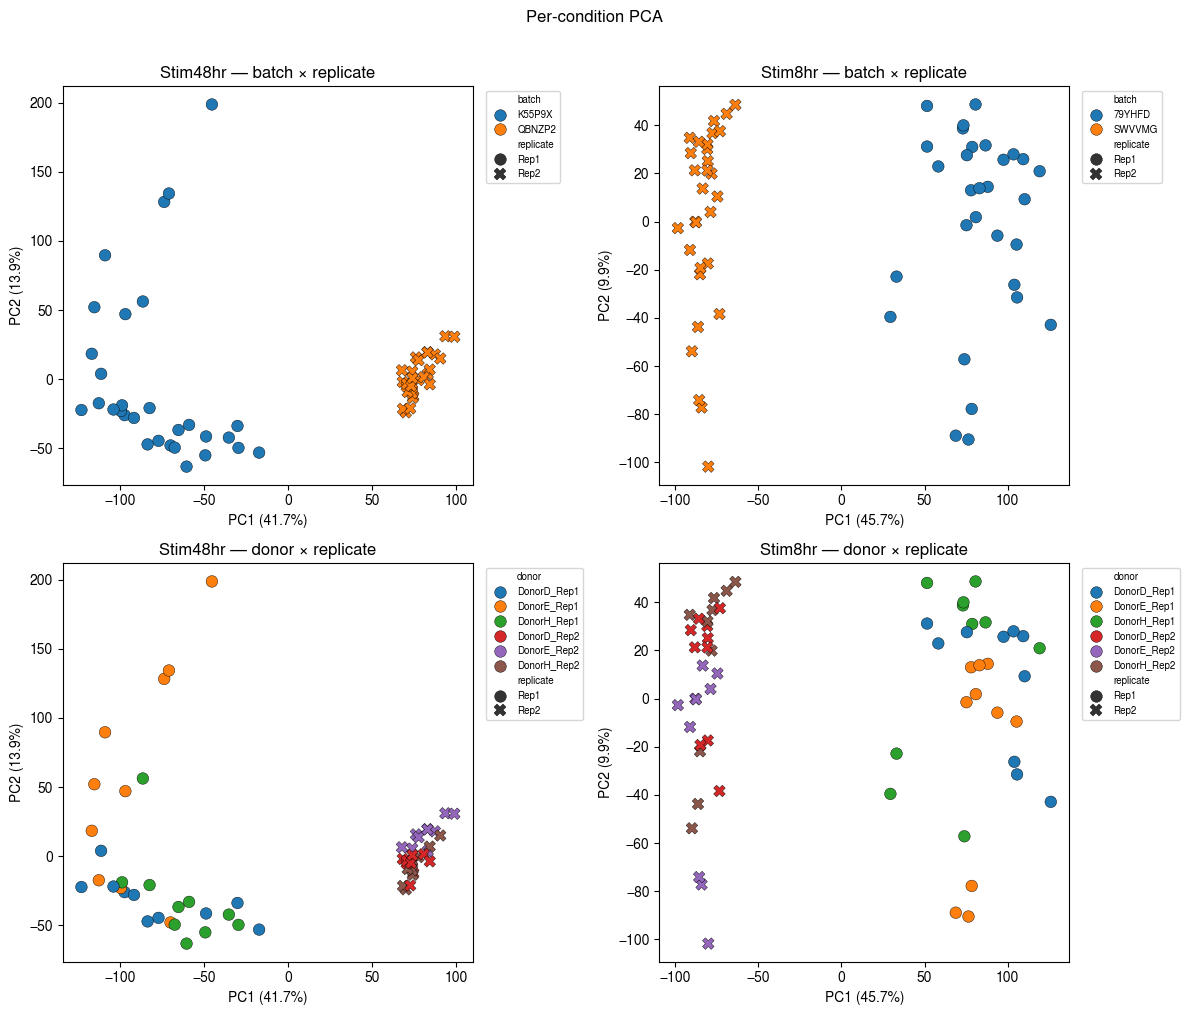

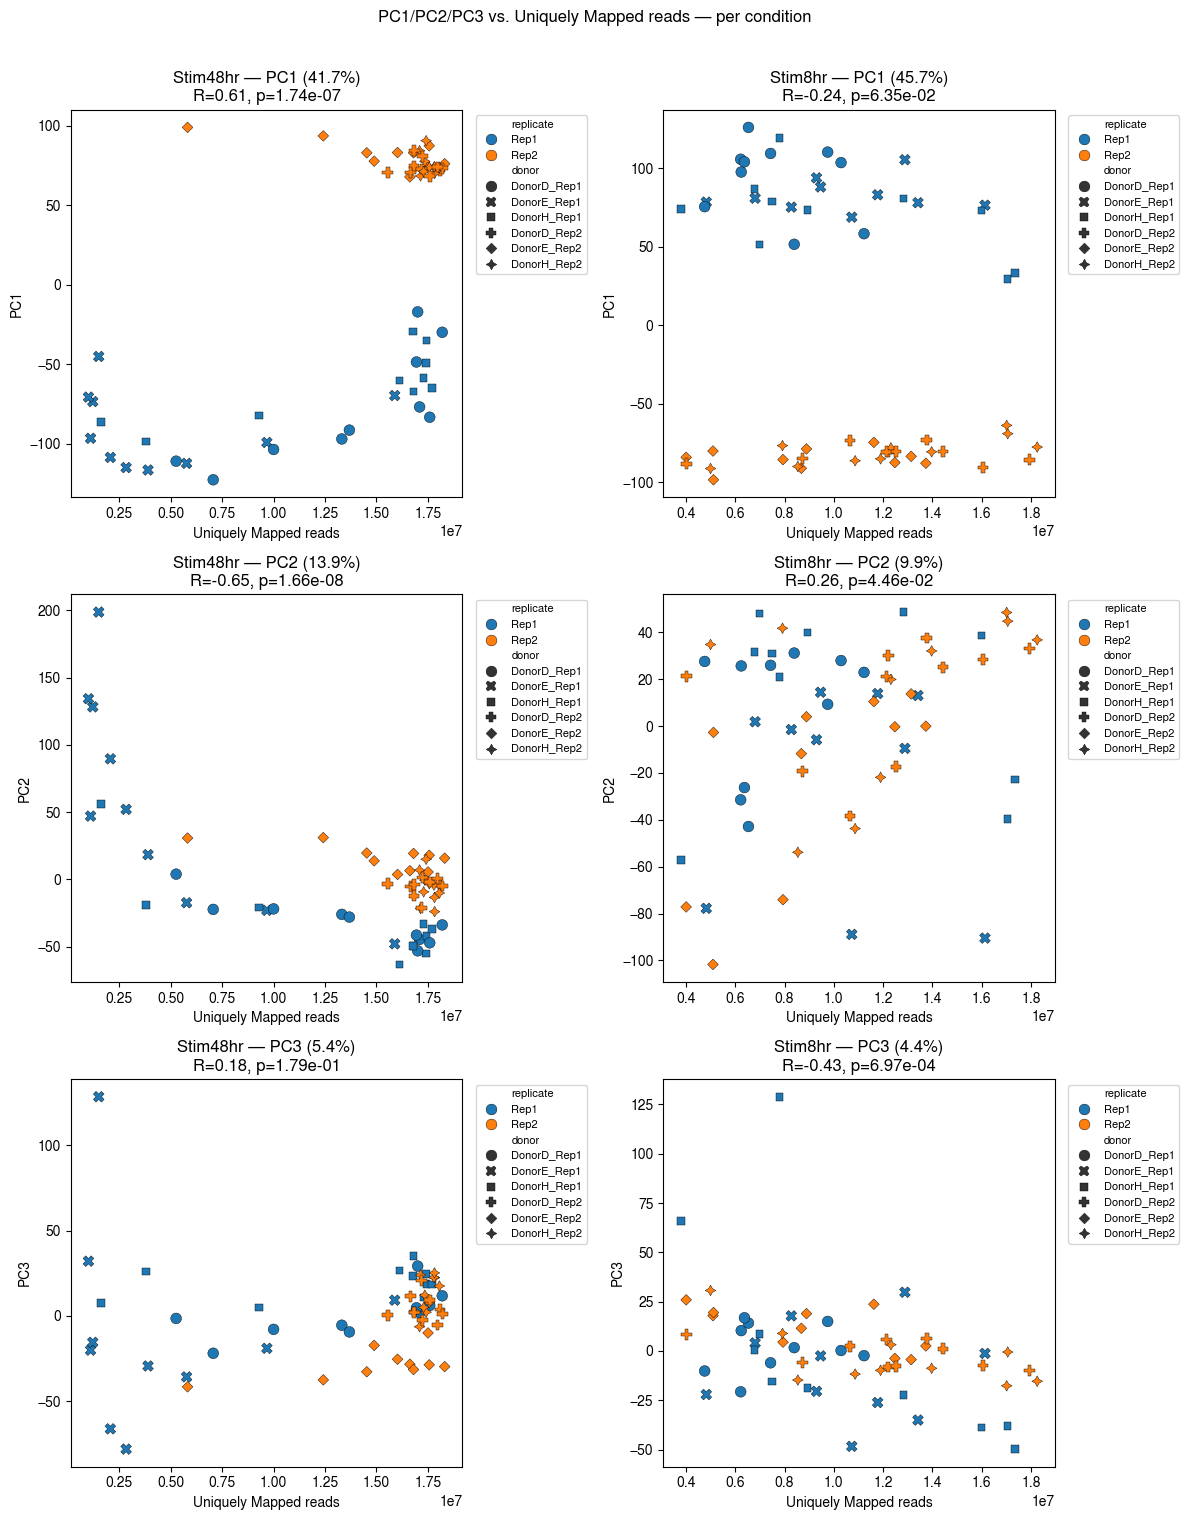

In [ ]:
# # Load mapping stats for sequencing-depth covariate
# mapping_parts = []
# for folder in sorted(result_folders):
#     prefix = folder.replace("_results", "")
#     stats = pd.read_csv(os.path.join(base_dir, folder, f"{prefix}-mapping-stats-reads.csv"), index_col=0)
#     smap = pd.read_csv(os.path.join(base_dir, folder, f"{prefix}_sample_name.csv"), encoding="utf-8-sig")
#     stats = stats.reset_index(drop=True)
#     stats['count_col'] = smap['sample_name'].values + '_count'
#     mapping_parts.append(stats)
# mapping_df = pd.concat(mapping_parts, ignore_index=True).set_index('count_col')

# # Per-condition PCA (PC1 used as sequencing-depth covariate in DESeq2)
# n_pcs = 10
# cond_pca_results = {}
# for cond in conditions:
#     sub = obs_df.index[obs_df['condition'] == cond]
#     lc = log_cpm[sub]
#     X = StandardScaler().fit_transform(lc.loc[lc.var(axis=1) > 0].T)
#     pca_obj = PCA(n_components=n_pcs).fit(X)
#     df_c = pd.DataFrame(
#         pca_obj.transform(X),
#         columns=[f'PC{i+1}' for i in range(n_pcs)],
#         index=sub
#     ).join(obs_df)
#     df_c['Uniquely Mapped'] = df_c.index.map(mapping_df['Uniquely Mapped'])
#     cond_pca_results[cond] = {'pca': pca_obj, 'df': df_c}

# # Plot: batch and donor separation per condition
# fig, axes = plt.subplots(2, len(conditions), figsize=(6 * len(conditions), 10))
# for j, cond in enumerate(conditions):
#     r = cond_pca_results[cond]
#     ev = r['pca'].explained_variance_ratio_
#     for i, (hue, title) in enumerate([('batch', 'batch × replicate'), ('donor', 'donor × replicate')]):
#         sns.scatterplot(data=r['df'], x='PC1', y='PC2', hue=hue, style='replicate',
#                         ax=axes[i, j], s=70, edgecolor='k', linewidth=0.3)
#         axes[i, j].set_xlabel(f'PC1 ({ev[0]:.1%})'); axes[i, j].set_ylabel(f'PC2 ({ev[1]:.1%})')
#         axes[i, j].set_title(f'{cond} — {title}')
#         axes[i, j].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
# plt.suptitle('Per-condition PCA', y=1.01)
# plt.tight_layout()
# plt.show()

# # Plot: PC1/PC2/PC3 vs. Uniquely Mapped reads to assess depth confounding
# pcs_to_plot = ['PC1', 'PC2', 'PC3']
# fig, axes = plt.subplots(len(pcs_to_plot), len(conditions),
#                          figsize=(6 * len(conditions), 5 * len(pcs_to_plot)))
# for i, pc in enumerate(pcs_to_plot):
#     for j, cond in enumerate(conditions):
#         ax = axes[i, j]
#         df_c = cond_pca_results[cond]['df'].dropna(subset=['Uniquely Mapped'])
#         ev = cond_pca_results[cond]['pca'].explained_variance_ratio_
#         r_val, p_val = scipy.stats.pearsonr(df_c['Uniquely Mapped'], df_c[pc])
#         sns.scatterplot(data=df_c, x='Uniquely Mapped', y=pc, hue='replicate', style='donor',
#                         s=60, edgecolor='k', linewidth=0.3, ax=ax)
#         ax.set_title(f"{cond} — {pc} ({ev[int(pc[2])-1]:.1%})\nR={r_val:.2f}, p={p_val:.2e}")
#         ax.set_xlabel('Uniquely Mapped reads')
#         ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
# plt.suptitle('PC1/PC2/PC3 vs. Uniquely Mapped reads — per condition', y=1.01)
# plt.tight_layout()
# plt.show()


# 3. DESeq2 Calculation

Design: `~ donor + PC1 + target_gene`  
PC1 is from the **per-condition** PCA (recomputed separately within each condition's samples).  
Results are saved to `results/`.

In [7]:
# all_results = []

# for cond in conditions:
#     cond_mask = obs_df['condition'] == cond
#     cond_counts = counts.loc[:, cond_mask]
#     cond_obs = obs_df.loc[cond_mask].copy()

#     adata = ad.AnnData(
#         X=np.rint(cond_counts.T.values).astype(int),
#         obs=cond_obs.reset_index(drop=True),
#         var=gene_meta.loc[cond_counts.index].copy()
#     )
#     adata.obs_names = [c.rsplit('_count', 1)[0] for c in cond_counts.columns]

#     # Attach per-condition PCA PCs as covariates. PC1 here is recomputed within
#     # this condition's samples (see cond_pca_results) and captures
#     # sequencing-depth / batch variation specific to this condition.
#     cond_pc_df = cond_pca_results[cond]['df']
#     for pc in ['PC1', 'PC2', 'PC3', 'PC4']:
#         adata.obs[pc] = [cond_pc_df.loc[f'{s}_count', pc] for s in adata.obs_names]

#     adata = adata[:, adata.var.gene_biotype == 'protein_coding'].copy()

#     print(f"\n=== {cond}: {adata.shape[0]} samples × {adata.shape[1]} genes ===")

#     # `donor` already encodes the replicate batch for Stim8hr/Stim48hr
#     # (donor = DonorX_RepY), so `replicate` is fully nested in `donor` and
#     # is omitted from the design to avoid collinearity.
#     model = pt.tl.PyDESeq2(adata, design='~ donor + PC1 + target_gene')
#     model.fit(quiet=True)

#     for t in perturbations:
#         contrast = model.cond(target_gene=t) - model.cond(target_gene='Non-targeting')
#         res = model.test_contrasts(contrast)
#         res['contrast'] = t
#         res['condition'] = cond
#         all_results.append(res)

# all_res_df = pd.concat(all_results).reset_index(drop=True)

# # Merge gene metadata (gene_name, gene_biotype) directly into the results so
# # downstream code only needs to handle a single dataframe.
# all_res_df = all_res_df.merge(
#     gene_meta.reset_index().rename(columns={'gene_id': 'variable'}),
#     on='variable', how='left'
# )
# print(f"\nTotal DE results: {all_res_df.shape}")

# all_res_df.to_csv(os.path.join(results_dir, "clusterTCR_deseq2_results.csv"), index=False)
# print(f"Saved DESeq2 results (with gene metadata) to {results_dir}/")


=== Stim48hr: 60 samples × 20120 genes ===


/Users/rzhu/miniconda3/envs/deseq/lib/python3.11/site-packages/pydeseq2/utils.py:380: RuntimeWarning: overflow encountered in exp
  mu_ = np.maximum(size_factors * np.exp(X @ beta), min_mu)
/Users/rzhu/miniconda3/envs/deseq/lib/python3.11/site-packages/pydeseq2/utils.py:234: RuntimeWarning: invalid value encountered in multiply
  - counts * np.log(mu)
/Users/rzhu/miniconda3/envs/deseq/lib/python3.11/site-packages/pydeseq2/utils.py:232: RuntimeWarning: invalid value encountered in subtract
  -logbinom
/Users/rzhu/miniconda3/envs/deseq/lib/python3.11/site-packages/pydeseq2/utils.py:384: RuntimeWarning: overflow encountered in exp
  mu_ = np.maximum(size_factors * np.exp(X @ beta), min_mu)
/Users/rzhu/miniconda3/envs/deseq/lib/python3.11/site-packages/pydeseq2/utils.py:387: RuntimeWarning: invalid value encountered in divide
  + ((1 / disp + counts) * mu_ / (1 / disp + mu_)) @ X
/Users/rzhu/miniconda3/envs/deseq/lib/python3.11/site-packages/pydeseq2/utils.py:380: RuntimeWarning: overflow 

Log2 fold change & Wald test p-value, contrast vector: [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. -1.  0.  0.]
                   baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene_id                                                                     
ENSG00000000003    9.442818       -0.152323  0.886901 -0.171747  0.863636   
ENSG00000000005    0.000000             NaN       NaN       NaN       NaN   
ENSG00000000419  841.658463        0.087047  0.110948  0.784575  0.432703   
ENSG00000000457   94.231871       -0.259688  0.107441 -2.417032  0.015648   
ENSG00000000460   95.351853       -0.120633  0.104853 -1.150500  0.249938   
...                     ...             ...       ...       ...       ...   
ENSG00000310558    0.000000             NaN       NaN       NaN       NaN   
ENSG00000310560   99.730067        0.045544  0.292226  0.155850  0.876151   
ENSG00000310561    0.008634       -0.521179  7.020187 -0.074240  0.940819   
ENSG00000310562    0.000000     

... done in 0.57 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value, contrast vector: [ 0.  0.  0.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0. -1.  0.  0.]
                   baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene_id                                                                     
ENSG00000000003    9.442818       -0.475038  0.863291 -0.550264  0.582139   
ENSG00000000005    0.000000             NaN       NaN       NaN       NaN   
ENSG00000000419  841.658463       -0.015189  0.107338 -0.141509  0.887468   
ENSG00000000457   94.231871       -0.260765  0.104097 -2.505018  0.012245   
ENSG00000000460   95.351853       -0.067180  0.102280 -0.656822  0.511295   
...                     ...             ...       ...       ...       ...   
ENSG00000310558    0.000000             NaN       NaN       NaN       NaN   
ENSG00000310560   99.730067       -0.182439  0.288043 -0.633375  0.526489   
ENSG00000310561    0.008634       -0.514082  6.786169 -0.075754  0.939615   
ENSG00000310562    0.000000     

...

Log2 fold change & Wald test p-value, contrast vector: [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  1. -1.  0.  0.]
                   baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene_id                                                                     
ENSG00000000003    6.473642        1.032457  0.560630  1.841603  0.065533   
ENSG00000000005    0.080649        0.565884  7.094958  0.079759  0.936429   
ENSG00000000419  385.343699        0.089710  0.079457  1.129038  0.258882   
ENSG00000000457   49.844612       -0.218674  0.190359 -1.148741  0.250663   
ENSG00000000460   12.488401       -0.310461  0.322712 -0.962036  0.336031   
...                     ...             ...       ...       ...       ...   
ENSG00000310558    0.014712        1.503933  7.165816  0.209876  0.833764   
ENSG00000310560   76.081789        0.454161  0.147138  3.086623  0.002024   
ENSG00000310561    0.009772        1.455581  7.165557  0.203136  0.839029   
ENSG00000310562    0.000000     

... done in 0.68 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value, contrast vector: [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. -1.  1.  0.]
                   baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene_id                                                                     
ENSG00000000003    6.473642        0.098021  0.521627  0.187915  0.850944   
ENSG00000000005    0.080649       -0.748812  6.792426 -0.110242  0.912217   
ENSG00000000419  385.343699       -0.030249  0.071253 -0.424536  0.671175   
ENSG00000000457   49.844612        0.082459  0.155504  0.530266  0.595928   
ENSG00000000460   12.488401       -0.080792  0.250582 -0.322417  0.747137   
...                     ...             ...       ...       ...       ...   
ENSG00000310558    0.014712        0.200441  6.862089  0.029210  0.976697   
ENSG00000310560   76.081789        0.207532  0.127119  1.632576  0.102558   
ENSG00000310561    0.009772        0.174910  6.865502  0.025477  0.979675   
ENSG00000310562    0.000000     

... done in 0.57 seconds.



Log2 fold change & Wald test p-value, contrast vector: [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. -1.  0.  1.]
                   baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene_id                                                                     
ENSG00000000003    6.473642       -0.070529  0.573060 -0.123074  0.902049   
ENSG00000000005    0.080649       -0.172666  6.912428 -0.024979  0.980072   
ENSG00000000419  385.343699       -0.196765  0.075970 -2.590037  0.009597   
ENSG00000000457   49.844612        0.494213  0.161560  3.058999  0.002221   
ENSG00000000460   12.488401       -0.444247  0.296087 -1.500396  0.133512   
...                     ...             ...       ...       ...       ...   
ENSG00000310558    0.014712        0.771344  6.985837  0.110415  0.912080   
ENSG00000310560   76.081789        0.313066  0.135307  2.313741  0.020682   
ENSG00000310561    0.009772        0.735133  6.990378  0.105164  0.916246   
ENSG00000310562    0.000000     

# 4. Pairwise Correlation Among Perturbations

For each pair of perturbation × condition observations, Pearson correlation is computed  
over the union of genes significant in either member of the pair (FDR < 0.1).  
Z-scores are capped at ±50 before correlation.

In [2]:
input_dir = "../../metadata/suppl_tables/"
results_dir = "./results"
os.makedirs(results_dir, exist_ok=True)

# Load DESeq2 results (gene metadata is merged into the same dataframe)
all_res_df = pd.read_csv(os.path.join(input_dir, "clusterTCR_deseq2_results.csv"))
print(f"Loaded DESeq2 results: {all_res_df.shape}")

conditions = all_res_df['condition'].unique().tolist()
perturbation_list = all_res_df['contrast'].unique().tolist()

# Pivot per condition and stat
stats = ['baseMean', 'log_fc', 'lfcSE', 'p_value', 'adj_p_value']
per_cond_stats = {
    cond: {
        stat: all_res_df[all_res_df['condition'] == cond].pivot(
            values=stat, columns='variable', index='contrast'
        )
        for stat in stats
    }
    for cond in conditions
}

all_gene_ids = sorted(set().union(*[per_cond_stats[c]['log_fc'].columns for c in conditions]))

# Build obs: all perturbation × condition combinations
obs_combined = pd.DataFrame(
    [{'sample': p, 'condition': c} for c in conditions for p in perturbation_list]
)
obs_combined.index = [f"{r['sample']}_{r['condition']}" for _, r in obs_combined.iterrows()]

# Stack layers across conditions (rows ordered by conditions, then perturbations)
layers = {
    stat: pd.concat([
        per_cond_stats[c][stat].reindex(index=perturbation_list, columns=all_gene_ids)
        for c in conditions
    ]).values
    for stat in stats
}

# Derive gene_id -> gene_name mapping directly from the merged dataframe
gene_name_map = (all_res_df[['variable', 'gene_name']]
                 .drop_duplicates('variable')
                 .set_index('variable')['gene_name'])
var_df = pd.DataFrame({
    'gene_id': all_gene_ids,
    'gene_name': [gene_name_map.get(g, g) for g in all_gene_ids]
}, index=all_gene_ids)

DE_anndata = ad.AnnData(layers=layers, obs=obs_combined, var=var_df)
DE_anndata.layers['zscore'] = np.clip(
    DE_anndata.layers['log_fc'] / DE_anndata.layers['lfcSE'], -50, 50
)
print(DE_anndata)


Loaded DESeq2 results: (362160, 11)
AnnData object with n_obs × n_vars = 18 × 20120
    obs: 'sample', 'condition'
    var: 'gene_id', 'gene_name'
    layers: 'baseMean', 'log_fc', 'lfcSE', 'p_value', 'adj_p_value', 'zscore'


In [3]:
# Pairwise Pearson correlation on zscore. On-target genes are masked per pair:
# for any pair (P1, P2), we drop the columns corresponding to gene P1 and gene P2
# so a perturbation's own knockdown signal can't inflate its correlations.
X = np.nan_to_num(DE_anndata.layers['zscore'].copy(), nan=0.0)
gene_names = DE_anndata.var['gene_name'].values
labels = DE_anndata.obs.index.tolist()
perts_per_row = DE_anndata.obs['sample'].values  # perturbation for each row

n = X.shape[0]
R = np.ones((n, n))
for i in range(n):
    for j in range(i + 1, n):
        on_target_mask = (gene_names == perts_per_row[i]) | (gene_names == perts_per_row[j])
        keep = ~on_target_mask
        xi, xj = X[i, keep], X[j, keep]
        # Pearson correlation
        xi_c = xi - xi.mean()
        xj_c = xj - xj.mean()
        denom = np.sqrt((xi_c**2).sum() * (xj_c**2).sum())
        R[i, j] = R[j, i] = (xi_c * xj_c).sum() / denom if denom > 0 else np.nan

corr_df = pd.DataFrame(R, index=labels, columns=labels)
corr_df

,ATP2A2_Stim48hr,ATP2A3_Stim48hr,CD3G_Stim48hr,GPI_Stim48hr,HEXD_Stim48hr,LAT_Stim48hr,MEN1_Stim48hr,SIK3_Stim48hr,VAV1_Stim48hr,ATP2A2_Stim8hr,ATP2A3_Stim8hr,CD3G_Stim8hr,GPI_Stim8hr,HEXD_Stim8hr,LAT_Stim8hr,MEN1_Stim8hr,SIK3_Stim8hr,VAV1_Stim8hr
ATP2A2_Stim48hr,1.000000,0.480152,-0.155239,-0.165303,0.214333,-0.168180,-0.100103,-0.206038,-0.279610,0.245327,-0.006259,-0.112108,-0.120086,-0.073147,-0.118492,0.026085,-0.092893,-0.134918
ATP2A3_Stim48hr,0.480152,1.000000,0.104617,0.158621,0.476228,0.072834,-0.020152,0.086948,-0.052647,0.064087,-0.031944,-0.259048,-0.045127,-0.129667,-0.224232,-0.013974,-0.109349,-0.255002
CD3G_Stim48hr,-0.155239,0.104617,1.000000,0.817809,0.369802,0.791480,0.507142,0.349302,0.793316,-0.048398,-0.096120,-0.337064,-0.084892,-0.186344,-0.295327,0.053199,-0.202939,-0.323385
GPI_Stim48hr,-0.165303,0.158621,0.817809,1.000000,0.445229,0.748695,0.605983,0.414264,0.751445,-0.063800,-0.030765,-0.402229,-0.027185,-0.173752,-0.376722,0.063013,-0.198231,-0.381513
HEXD_Stim48hr,0.214333,0.476228,0.369802,0.445229,1.000000,0.442125,0.318569,0.333693,0.319412,0.064978,-0.034610,-0.178467,-0.015943,-0.021104,-0.146156,-0.033764,-0.090386,-0.167741
LAT_Stim48hr,-0.168180,0.072834,0.791480,0.748695,0.442125,1.000000,0.635615,0.492195,0.867385,-0.062693,-0.067576,-0.130981,-0.029039,-0.103335,-0.103582,-0.009154,-0.100988,-0.129676
MEN1_Stim48hr,-0.100103,-0.020152,0.507142,0.605983,0.318569,0.635615,1.000000,0.514226,0.705916,0.102357,0.142566,-0.003036,0.035095,0.072321,-0.038725,0.286999,0.037792,-0.006300
SIK3_Stim48hr,-0.206038,0.086948,0.349302,0.414264,0.333693,0.492195,0.514226,1.000000,0.540440,-0.066209,0.124264,0.072200,0.115025,0.088167,0.005844,0.054696,0.163121,0.048091
VAV1_Stim48hr,-0.279610,-0.052647,0.793316,0.751445,0.319412,0.867385,0.705916,0.540440,1.000000,-0.068801,0.001917,-0.062455,0.001492,-0.022103,-0.057905,0.078623,-0.051192,-0.059151
ATP2A2_Stim8hr,0.245327,0.064087,-0.048398,-0.063800,0.064978,-0.062693,0.102357,-0.066209,-0.068801,1.000000,0.297767,0.161586,0.142994,0.249896,0.200877,0.247001,0.224582,0.186804


# 5. Dotplot: Early/Late Regulators vs Core Regulators

Each point shows the pairwise correlation (from the union-gene matrix) between a regulator  
and a core TCR signaling gene (CD3G, LAT, VAV1), split by Stim8hr vs Stim48hr.

- **Early regulators**: ATP2A2, ATP2A3, HEXDC  
- **Late regulators**: MEN1, GPI, SIK3  
- **Core regulators**: CD3G, LAT, VAV1

Paired t-test (Stim8hr vs Stim48hr) per regulator — raw p / BH q:
  ATP2A2   p=0.0128   q=0.0295
  ATP2A3   p=0.0428   q=0.0513
  HEXD     p=0.0331   q=0.0497
  MEN1     p=0.0148   q=0.0295
  GPI      p=0.0044   q=0.0264
  SIK3     p=0.928   q=0.928
Saved figure to ../../metadata/suppl_tables/clusterTCR_corr_dotplot.[pdf|svg|png]


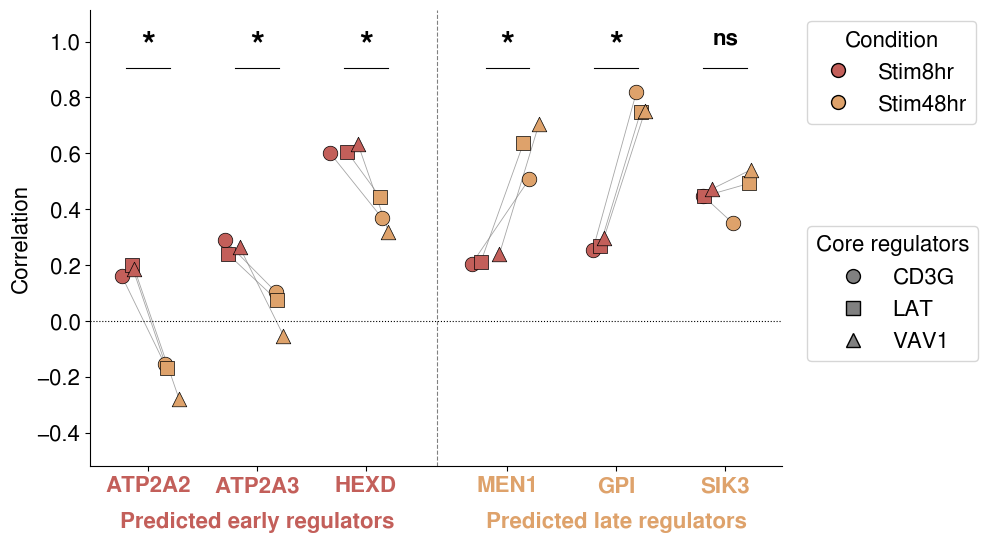

In [16]:
early_regulators = ['ATP2A2', 'ATP2A3', 'HEXD']
late_regulators  = ['MEN1', 'GPI', 'SIK3']
core_regulators  = ['CD3G', 'LAT', 'VAV1']
plot_conditions  = ['Stim8hr', 'Stim48hr']  # Stim8hr drawn first
EARLY_COLOR = '#c35f5a'  # Stim8hr + early regulators
LATE_COLOR  = '#dea26b'  # Stim48hr + late regulators
palette = {'Stim8hr': EARLY_COLOR, 'Stim48hr': LATE_COLOR}
core_markers = {'CD3G': 'o', 'LAT': 's', 'VAV1': '^'}

regulator_order = early_regulators + late_regulators

# Extra horizontal gap between the early and late regulator groups
GROUP_GAP = 0.3
x_pos = {r: (i if i < len(early_regulators) else i + GROUP_GAP)
         for i, r in enumerate(regulator_order)}
group_divider_x = (x_pos[early_regulators[-1]] + x_pos[late_regulators[0]]) / 2

# Build long-form dataframe (ordered: Stim8hr before Stim48hr; early before late)
plot_rows = []
for group, regs in [('Early', early_regulators), ('Late', late_regulators)]:
    for reg in regs:
        for core in core_regulators:
            for cond in plot_conditions:
                val = corr_df.loc[f"{reg}_{cond}", f"{core}_{cond}"]
                plot_rows.append({
                    'regulator': reg, 'group': group,
                    'core': core, 'condition': cond, 'correlation': val
                })
plot_df = pd.DataFrame(plot_rows)
plot_df['regulator'] = pd.Categorical(plot_df['regulator'], categories=regulator_order, ordered=True)
plot_df['condition'] = pd.Categorical(plot_df['condition'], categories=plot_conditions, ordered=True)

def sig_stars(p):
    if np.isnan(p): return 'n/a'
    if p < 1e-4: return '****'
    if p < 1e-3: return '***'
    if p < 1e-2: return '**'
    if p < 1e-1: return '*'
    return 'ns'

def bh_fdr(pvals):
    p = np.asarray(pvals, dtype=float)
    ok = ~np.isnan(p)
    q = np.full_like(p, np.nan)
    if ok.sum() == 0:
        return q
    idx = np.where(ok)[0]
    order = np.argsort(p[idx])
    ranked = p[idx][order]
    n = len(ranked)
    adj = ranked * n / (np.arange(n) + 1)
    adj = np.minimum.accumulate(adj[::-1])[::-1]
    adj = np.clip(adj, 0, 1)
    q[idx[order]] = adj
    return q

# Paired t-test per regulator: pair Stim8hr vs Stim48hr across the 3 core genes.
pvals_raw = []
for reg in regulator_order:
    sub = plot_df[plot_df['regulator'] == reg].sort_values('core')
    a = sub[sub['condition'] == 'Stim8hr'].set_index('core')['correlation']
    b = sub[sub['condition'] == 'Stim48hr'].set_index('core')['correlation']
    paired = pd.concat([a, b], axis=1, keys=['Stim8hr', 'Stim48hr']).dropna()
    if len(paired) >= 2:
        _, p = scipy.stats.ttest_rel(paired['Stim8hr'], paired['Stim48hr'])
    else:
        p = np.nan
    pvals_raw.append(p)
qvals = bh_fdr(pvals_raw)
print("Paired t-test (Stim8hr vs Stim48hr) per regulator — raw p / BH q:")
for r, p, q in zip(regulator_order, pvals_raw, qvals):
    print(f"  {r:7s}  p={p:.3g}   q={q:.3g}")

fig, ax = plt.subplots(figsize=(10, 5.5))

# Per-regulator point placement. Each (regulator x condition) cell has 3 points
# (one per core gene) on distinct sub-slots within the dodged half-cell, plus
# a small random jitter.
HALF_WIDTH = 0.4
SUB_SLOTS  = np.linspace(-0.30, 0.30, len(core_regulators))
SUB_JITTER = 0.07
rng = np.random.default_rng(0)
cond_dodge = {'Stim8hr': -HALF_WIDTH / 2, 'Stim48hr': HALF_WIDTH / 2}

point_xy = {}  # (regulator, core, condition) -> (x, y)
for ci, core in enumerate(core_regulators):
    sub_slot = SUB_SLOTS[ci] * (HALF_WIDTH / 2)
    for cond in plot_conditions:
        sub = plot_df[(plot_df['core'] == core) & (plot_df['condition'] == cond)]
        if sub.empty:
            continue
        x_base = np.array([x_pos[r] for r in sub['regulator']], dtype=float)
        x = x_base + cond_dodge[cond] + sub_slot
        x = x + rng.uniform(-SUB_JITTER, SUB_JITTER, size=len(x))
        ax.scatter(
            x, sub['correlation'].values,
            marker=core_markers[core], color=palette[cond],
            s=110, edgecolor='k', linewidth=0.5, zorder=3,
        )
        for xi, yi, reg in zip(x, sub['correlation'].values, sub['regulator']):
            point_xy[(reg, core, cond)] = (xi, yi)

# Thin connector lines: link Stim8hr and Stim48hr points of the same core gene
# within each regulator (the pairs the paired t-test uses).
for reg in regulator_order:
    for core in core_regulators:
        a = point_xy.get((reg, core, 'Stim8hr'))
        b = point_xy.get((reg, core, 'Stim48hr'))
        if a is None or b is None or np.isnan(a[1]) or np.isnan(b[1]):
            continue
        ax.plot([a[0], b[0]], [a[1], b[1]],
                color='gray', linewidth=0.6, alpha=0.7, zorder=2)

ax.axhline(0, color='k', linewidth=0.8, linestyle=':')
ax.axvline(group_divider_x, color='gray', linewidth=0.8, linestyle='--')
ax.set_xticks([x_pos[r] for r in regulator_order])
ax.set_xticklabels(regulator_order)
ax.set_xlabel("")
ax.set_ylabel("Correlation", fontsize=16)
ax.set_title("")
ax.tick_params(axis='both', labelsize=16)

# Color + bold the regulator tick labels by group
for tick, reg in zip(ax.get_xticklabels(), regulator_order):
    tick.set_color(EARLY_COLOR if reg in early_regulators else LATE_COLOR)
    tick.set_fontweight('bold')

# Significance bars + annotations (BH-FDR adjusted). Asterisks render large;
# 'ns' renders smaller so it doesn't dominate the figure.
ymax_data = plot_df['correlation'].max()
ymin_data = plot_df['correlation'].min()
yrange = ymax_data - ymin_data
bar_y = ymax_data + 0.08 * yrange
star_y = bar_y + 0.01 * yrange
ns_y   = bar_y + 0.06 * yrange  # 'ns' sits a bit higher than the bar
for reg, q in zip(regulator_order, qvals):
    label = sig_stars(q)
    xc = x_pos[reg]
    ax.plot([xc - 0.2, xc + 0.2], [bar_y, bar_y], color='k', linewidth=0.8)
    if label == 'ns':
        ax.text(xc, ns_y, label, ha='center', va='bottom',
                fontsize=16, fontweight='bold')
    else:
        ax.text(xc, star_y, label, ha='center', va='bottom',
                fontsize=26, fontweight='bold')

# Reserve room below the axes for the Early/Late group labels
ax.set_ylim(ymin_data - 0.22 * yrange, star_y + 0.18 * yrange)

# Two legends: condition (color) and core (marker)
cond_handles = [plt.Line2D([0], [0], marker='o', linestyle='', color=palette[c],
                           markeredgecolor='k', markersize=10, label=c)
                for c in plot_conditions]
core_handles = [plt.Line2D([0], [0], marker=core_markers[c], linestyle='', color='gray',
                           markeredgecolor='k', markersize=10, label=c)
                for c in core_regulators]
leg1 = ax.legend(handles=cond_handles, title='Condition',
                 bbox_to_anchor=(1.02, 1), loc='upper left',
                 fontsize=16, title_fontsize=16)
ax.add_artist(leg1)
ax.legend(handles=core_handles, title='Core regulators',
          bbox_to_anchor=(1.02, 0.55), loc='upper left',
          fontsize=16, title_fontsize=16)

# Predicted Early / Late group labels — placed below the tick labels.
# get_xaxis_transform: x in data coords, y in axes coords (0 = bottom of axes).
early_x = np.mean([x_pos[r] for r in early_regulators])
late_x  = np.mean([x_pos[r] for r in late_regulators])
ax.text(early_x, -0.1, 'Predicted early regulators', transform=ax.get_xaxis_transform(),
        ha='center', va='top', fontsize=16, fontweight='bold', color=EARLY_COLOR)
ax.text(late_x,  -0.1, 'Predicted late regulators',  transform=ax.get_xaxis_transform(),
        ha='center', va='top', fontsize=16, fontweight='bold', color=LATE_COLOR)

sns.despine(ax=ax)
plt.tight_layout()

# Save figure (PDF/SVG for editable vector output, PNG for quick viewing)
fig_stem = os.path.join(results_dir, 'clusterTCR_corr_dotplot')
fig.savefig(f'{fig_stem}.pdf', bbox_inches='tight')
fig.savefig(f'{fig_stem}.svg', bbox_inches='tight')
fig.savefig(f'{fig_stem}.png', dpi=300, bbox_inches='tight')
print(f"Saved figure to {fig_stem}.[pdf|svg|png]")

plt.show()

Saved figure to ./results/clusterTCR_MEN1_vs_VAV1_Stim8hr_scatter.[pdf|svg|png]


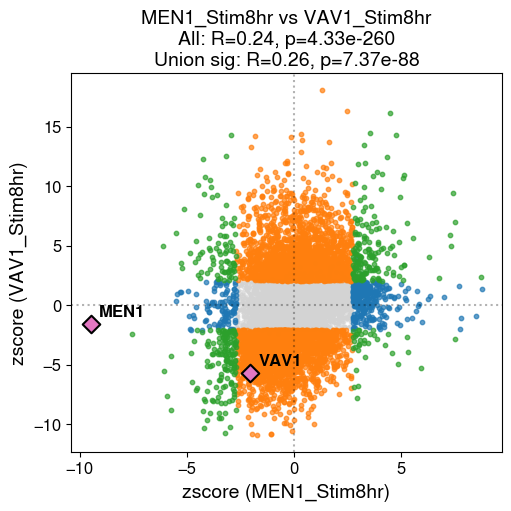

Saved figure to ./results/clusterTCR_MEN1_vs_VAV1_Stim48hr_scatter.[pdf|svg|png]


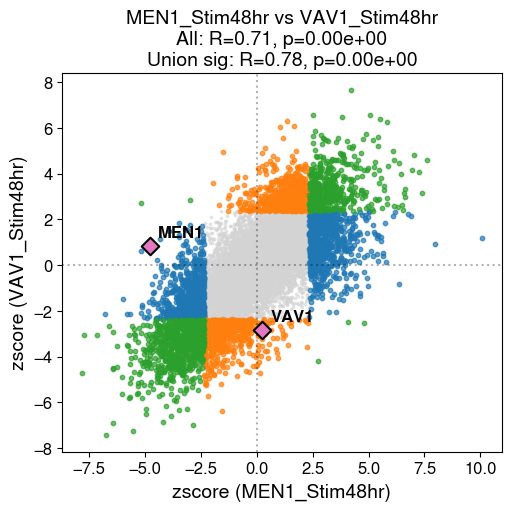

In [4]:
# Scatterplots: bulkRNAseq z-scores for two chosen regulators. One figure per
# condition (Stim8hr, Stim48hr), saved to its own set of files.
# Configure regulators with X_GENE / Y_GENE.
# Dots are rasterized so the vector PDF/SVG output stays small while the
# surrounding text/axes remain editable.
from scipy.stats import pearsonr

X_GENE = 'MEN1'
Y_GENE = 'VAV1'
SAVE_DPI = 600   # rasterization DPI for PDF/SVG/PNG

# Shared color palette — reused by the standalone-legend cell.
SCATTER_COLORS = {
    'ns':        'lightgray',
    'x_only':    '#1f77b4',
    'y_only':    '#ff7f0e',
    'both':      '#2ca02c',
    'on_target': '#e377c2',
}


def plot_bulk_vs_bulk_scatter(DE_anndata, sample_x, sample_y,
                              adj_p_thres=0.1, ax=None):
    """Scatter of bulkRNAseq z-scores between two perturbation x condition samples."""
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(4, 4))

    gene_names = DE_anndata.var['gene_name'].values

    x_zscore = DE_anndata.layers['zscore'][DE_anndata.obs.index == sample_x].flatten().copy()
    y_zscore = DE_anndata.layers['zscore'][DE_anndata.obs.index == sample_y].flatten().copy()
    x_padj   = DE_anndata.layers['adj_p_value'][DE_anndata.obs.index == sample_x].flatten().copy()
    y_padj   = DE_anndata.layers['adj_p_value'][DE_anndata.obs.index == sample_y].flatten().copy()

    # Mask on-target genes so they don't dominate the correlation
    pert_x, pert_y = sample_x.split('_')[0], sample_y.split('_')[0]
    on_target_perts = list(set([pert_x, pert_y]))
    on_target_mask = np.zeros(len(gene_names), dtype=bool)
    on_target_vals = {}
    for pert in on_target_perts:
        ot = gene_names == pert
        if ot.any():
            on_target_mask |= ot
            on_target_vals[pert] = (x_zscore[ot].copy(), y_zscore[ot].copy())
            x_zscore[ot] = 0; y_zscore[ot] = 0
            x_padj[ot] = 1;   y_padj[ot] = 1

    x_z = np.nan_to_num(x_zscore, nan=0)
    y_z = np.nan_to_num(y_zscore, nan=0)
    x_p = np.nan_to_num(x_padj, nan=1.0)
    y_p = np.nan_to_num(y_padj, nan=1.0)

    sig_x = x_p < adj_p_thres
    sig_y = y_p < adj_p_thres
    sig_either = sig_x | sig_y
    mask_both   = sig_x &  sig_y
    mask_x_only = sig_x & ~sig_y
    mask_y_only = ~sig_x &  sig_y
    mask_ns     = ~(sig_x | sig_y)

    ax.scatter(x_z[mask_ns],     y_z[mask_ns],     c=SCATTER_COLORS['ns'],     s=3,  alpha=0.5, rasterized=True)
    ax.scatter(x_z[mask_x_only], y_z[mask_x_only], c=SCATTER_COLORS['x_only'], s=10, alpha=0.7, rasterized=True)
    ax.scatter(x_z[mask_y_only], y_z[mask_y_only], c=SCATTER_COLORS['y_only'], s=10, alpha=0.7, rasterized=True)
    ax.scatter(x_z[mask_both],   y_z[mask_both],   c=SCATTER_COLORS['both'],   s=10, alpha=0.7, rasterized=True)

    # All on-target genes plotted with the same marker, labeled by gene name
    for pert, (ox, oy) in on_target_vals.items():
        ax.scatter(ox, oy, c=SCATTER_COLORS['on_target'], s=80, marker='D',
                   edgecolors='black', linewidth=1.5, zorder=12, rasterized=True)
        for xi, yi in zip(ox, oy):
            if np.isnan(xi) or np.isnan(yi):
                continue
            ax.annotate(pert, xy=(xi, yi), xytext=(6, 6),
                        textcoords='offset points', fontsize=12,
                        fontweight='bold', color='black', zorder=13)

    off_target = ~on_target_mask
    x_off, y_off = x_z[off_target], y_z[off_target]
    r_all, p_all = pearsonr(x_off, y_off) if len(x_off) > 1 else (np.nan, np.nan)

    mask_union = sig_either & off_target
    if mask_union.sum() > 1:
        r_sig, p_sig = pearsonr(x_z[mask_union], y_z[mask_union])
        stats_text = f"All: R={r_all:.2f}, p={p_all:.2e}\nUnion sig: R={r_sig:.2f}, p={p_sig:.2e}"
    else:
        stats_text = f"All: R={r_all:.2f}, p={p_all:.2e}\nUnion sig: N/A"

    ax.set_title(f"{sample_x} vs {sample_y}\n{stats_text}", fontsize=14)
    ax.axhline(0, color='k', linestyle=':', alpha=0.3)
    ax.axvline(0, color='k', linestyle=':', alpha=0.3)
    ax.set_xlabel(f"zscore ({sample_x})", fontsize=14)
    ax.set_ylabel(f"zscore ({sample_y})", fontsize=14)
    ax.tick_params(labelsize=12)
    return ax


for cond in ['Stim8hr', 'Stim48hr']:
    fig, ax = plt.subplots(figsize=(5, 5), constrained_layout=True)
    plot_bulk_vs_bulk_scatter(
        DE_anndata,
        sample_x=f'{X_GENE}_{cond}',
        sample_y=f'{Y_GENE}_{cond}',
        ax=ax,
    )

    fig_stem = os.path.join(results_dir, f'clusterTCR_{X_GENE}_vs_{Y_GENE}_{cond}_scatter')
    # dpi controls the resolution of rasterized artists when writing to PDF/SVG.
    fig.savefig(f'{fig_stem}.pdf', bbox_inches='tight', dpi=SAVE_DPI)
    fig.savefig(f'{fig_stem}.svg', bbox_inches='tight', dpi=SAVE_DPI)
    fig.savefig(f'{fig_stem}.png', bbox_inches='tight', dpi=SAVE_DPI)
    print(f"Saved figure to {fig_stem}.[pdf|svg|png]")
    plt.show()

Saved legend to results/clusterTCR_GPI_vs_CD3G_scatter_legend.[pdf|svg|png]


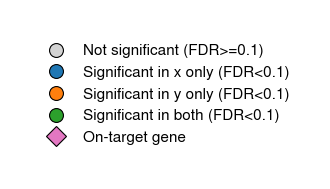

In [12]:
# Standalone legend for the GPI vs CD3G scatter panels.
legend_entries = [
    ('Not significant (FDR>=0.1)',            SCATTER_COLORS['ns'],        'o'),
    ('Significant in x only (FDR<0.1)',       SCATTER_COLORS['x_only'],    'o'),
    ('Significant in y only (FDR<0.1)',       SCATTER_COLORS['y_only'],    'o'),
    ('Significant in both (FDR<0.1)',         SCATTER_COLORS['both'],      'o'),
    ('On-target gene',                        SCATTER_COLORS['on_target'], 'D'),
]
handles = [
    plt.Line2D([0], [0], marker=m, linestyle='', color=c,
               markeredgecolor='black', markeredgewidth=0.8, markersize=10, label=lbl)
    for lbl, c, m in legend_entries
]

fig_leg = plt.figure(figsize=(4, 2.2))
fig_leg.legend(handles=handles, loc='center', frameon=False, fontsize=11,
               handletextpad=0.8, borderaxespad=0)
plt.axis('off')

leg_stem = os.path.join(results_dir, 'clusterTCR_GPI_vs_CD3G_scatter_legend')
fig_leg.savefig(f'{leg_stem}.pdf', bbox_inches='tight')
fig_leg.savefig(f'{leg_stem}.svg', bbox_inches='tight')
fig_leg.savefig(f'{leg_stem}.png', dpi=300, bbox_inches='tight')
print(f"Saved legend to {leg_stem}.[pdf|svg|png]")
plt.show()